<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




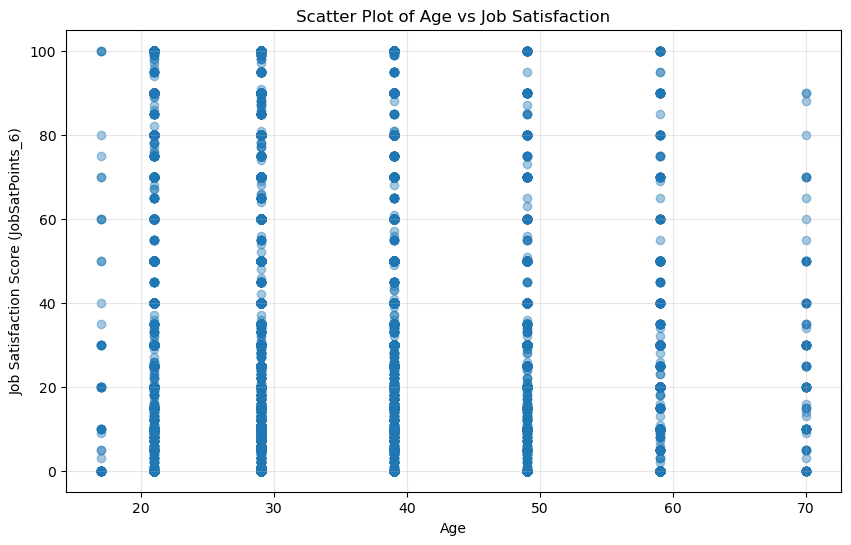

In [3]:
# Convert Age categories into approximate numeric values
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70
}

df['Age_Numeric'] = df['Age'].map(age_mapping)

# Convert JobSatPoints_6 to numeric
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Remove missing values
df_scatter = df[['Age_Numeric', 'JobSatPoints_6']].dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_scatter['Age_Numeric'],
    df_scatter['JobSatPoints_6'],
    alpha=0.4
)

plt.title('Scatter Plot of Age vs Job Satisfaction')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction Score (JobSatPoints_6)')
plt.grid(True, alpha=0.3)

plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


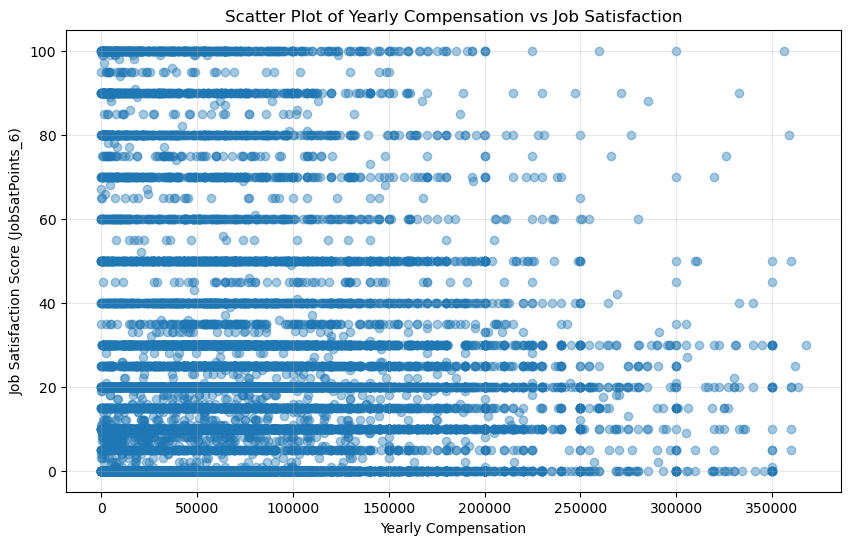

In [4]:
# Convert columns to numeric
df['ConvertedCompYearly'] = pd.to_numeric(
    df['ConvertedCompYearly'],
    errors='coerce'
)

df['JobSatPoints_6'] = pd.to_numeric(
    df['JobSatPoints_6'],
    errors='coerce'
)

# Keep only required columns and remove missing values
df_scatter = df[['ConvertedCompYearly', 'JobSatPoints_6']].dropna()

# Remove extreme compensation outliers using 99th percentile
upper_limit = df_scatter['ConvertedCompYearly'].quantile(0.99)
df_scatter = df_scatter[df_scatter['ConvertedCompYearly'] <= upper_limit]

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_scatter['ConvertedCompYearly'],
    df_scatter['JobSatPoints_6'],
    alpha=0.4
)

plt.title('Scatter Plot of Yearly Compensation vs Job Satisfaction')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction Score (JobSatPoints_6)')
plt.grid(True, alpha=0.3)

plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


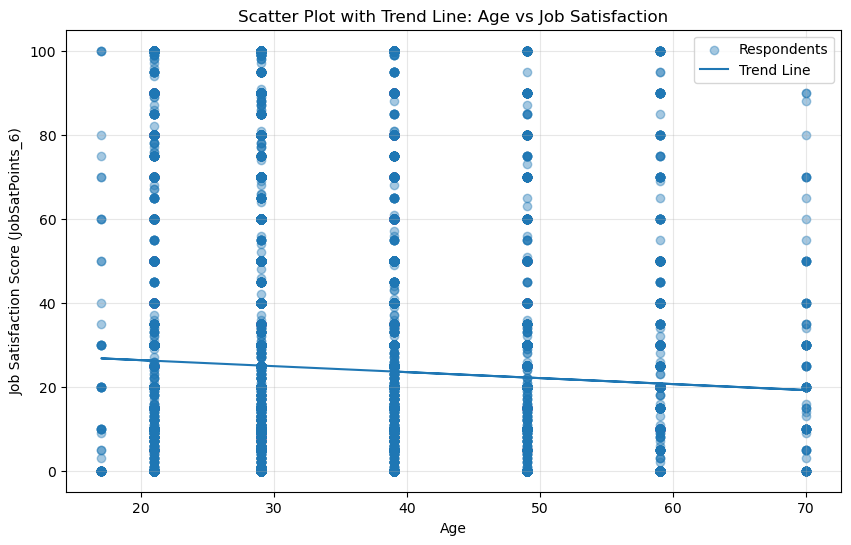

In [5]:
import numpy as np

# Convert Age categories into approximate numeric values

age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70
}

df['Age_Numeric'] = df['Age'].map(age_mapping)

# Convert JobSatPoints_6 to numeric
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Remove missing values
df_trend = df[['Age_Numeric', 'JobSatPoints_6']].dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_trend['Age_Numeric'],
    df_trend['JobSatPoints_6'],
    alpha=0.4,
    label='Respondents'
)

# Add regression trend line
x = df_trend['Age_Numeric']
y = df_trend['JobSatPoints_6']

slope, intercept = np.polyfit(x, y, 1)
trend_line = slope * x + intercept

plt.plot(
    x,
    trend_line,
    label='Trend Line'
)

plt.title('Scatter Plot with Trend Line: Age vs Job Satisfaction')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction Score (JobSatPoints_6)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


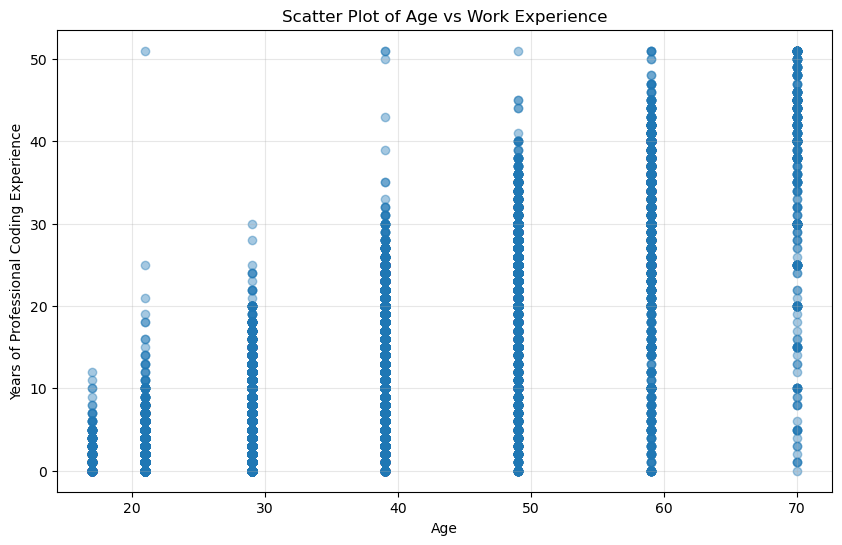

In [6]:
# Convert Age categories into approximate numeric values
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70    
}

df['Age_Numeric'] = df['Age'].map(age_mapping)

# Convert YearsCodePro into numeric values
df['YearsCodePro_Numeric'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 51
})

df['YearsCodePro_Numeric'] = pd.to_numeric(
    df['YearsCodePro_Numeric'],
    errors='coerce'
)

# Remove missing values
df_scatter = df[['Age_Numeric', 'YearsCodePro_Numeric']].dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_scatter['Age_Numeric'],
    df_scatter['YearsCodePro_Numeric'],
    alpha=0.4
)

plt.title('Scatter Plot of Age vs Work Experience')
plt.xlabel('Age')
plt.ylabel('Years of Professional Coding Experience')
plt.grid(True, alpha=0.3)

plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


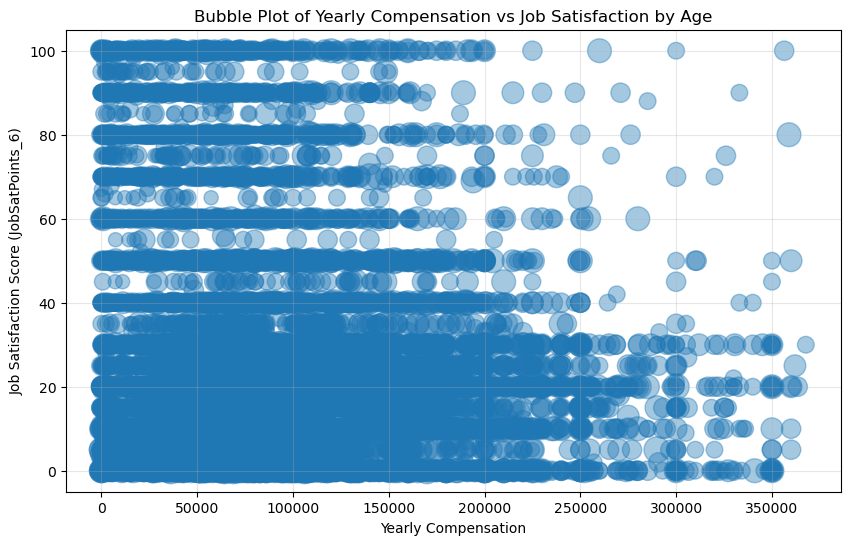

In [7]:
# Convert Age categories into approximate numeric values
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70
}

df['Age_Numeric'] = df['Age'].map(age_mapping)

# Convert compensation and job satisfaction columns to numeric
df['ConvertedCompYearly'] = pd.to_numeric(
    df['ConvertedCompYearly'],
    errors='coerce'
)

df['JobSatPoints_6'] = pd.to_numeric(
    df['JobSatPoints_6'],
    errors='coerce'
)

# Keep only required columns and remove missing values
df_bubble = df[
    ['ConvertedCompYearly', 'JobSatPoints_6', 'Age_Numeric']
].dropna()

# Remove extreme compensation outliers using 99th percentile
upper_limit = df_bubble['ConvertedCompYearly'].quantile(0.99)
df_bubble = df_bubble[df_bubble['ConvertedCompYearly'] <= upper_limit]

# Create bubble plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_bubble['ConvertedCompYearly'],
    df_bubble['JobSatPoints_6'],
    s=df_bubble['Age_Numeric'] * 5,   # bubble size based on age
    alpha=0.4
)

plt.title('Bubble Plot of Yearly Compensation vs Job Satisfaction by Age')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction Score (JobSatPoints_6)')
plt.grid(True, alpha=0.3)

plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


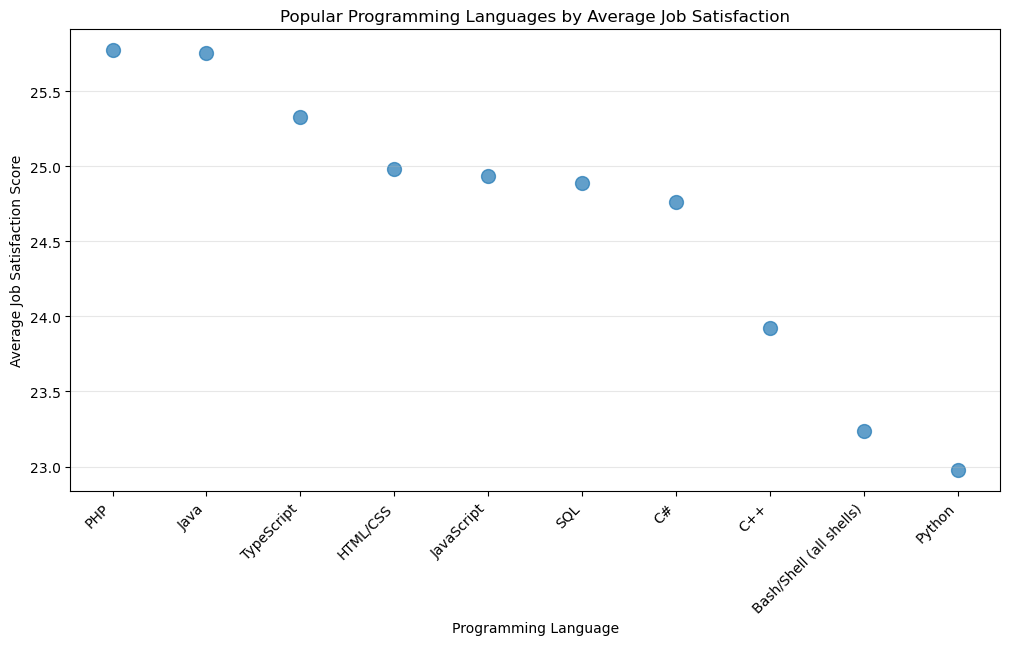

In [8]:
# Convert JobSatPoints_6 to numeric
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Keep only required columns and remove missing values
df_lang = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna()

# Split multiple languages separated by ;
df_lang['LanguageHaveWorkedWith'] = df_lang['LanguageHaveWorkedWith'].str.split(';')

# Explode so each language gets its own row
df_lang = df_lang.explode('LanguageHaveWorkedWith')

# Remove extra spaces
df_lang['LanguageHaveWorkedWith'] = df_lang['LanguageHaveWorkedWith'].str.strip()

# Find top 10 most popular languages
top_languages = df_lang['LanguageHaveWorkedWith'].value_counts().head(10).index

# Filter only top 10 languages
df_top_lang = df_lang[df_lang['LanguageHaveWorkedWith'].isin(top_languages)]

# Calculate average job satisfaction for each language
avg_satisfaction = (
    df_top_lang
    .groupby('LanguageHaveWorkedWith')['JobSatPoints_6']
    .mean()
    .sort_values(ascending=False)
)

# Create scatter plot
plt.figure(figsize=(12, 6))

plt.scatter(
    avg_satisfaction.index,
    avg_satisfaction.values,
    s=100,
    alpha=0.7
)

plt.title('Popular Programming Languages by Average Job Satisfaction')
plt.xlabel('Programming Language')
plt.ylabel('Average Job Satisfaction Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


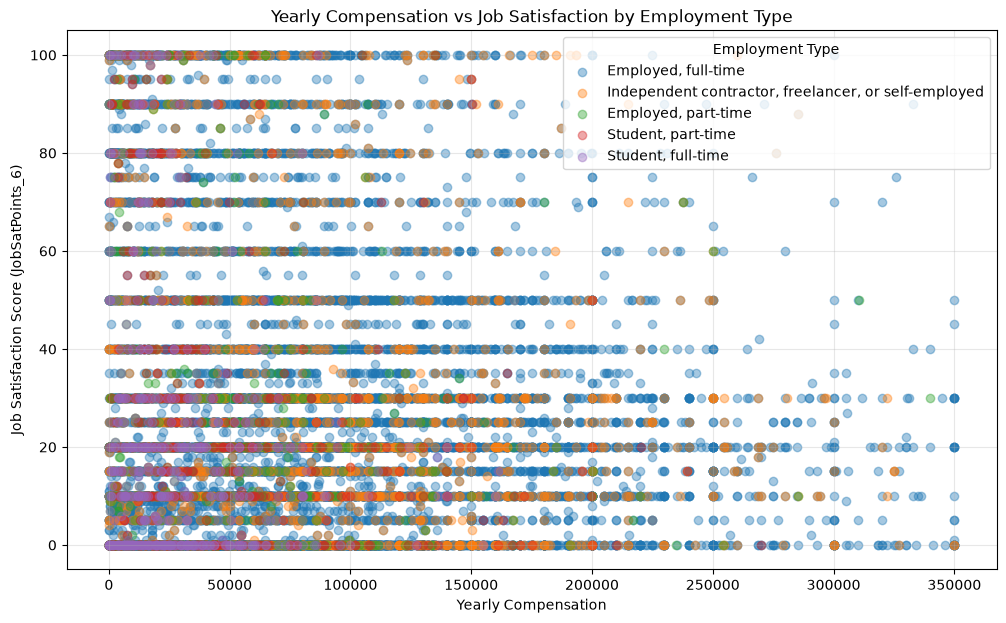

In [11]:
# Convert numeric columns
df['ConvertedCompYearly'] = pd.to_numeric(
    df['ConvertedCompYearly'],
    errors='coerce'
)

df['JobSatPoints_6'] = pd.to_numeric(
    df['JobSatPoints_6'],
    errors='coerce'
)

# Keep required columns and remove missing values
df_emp = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']].dropna()

# Employment can contain multiple values separated by ;
df_emp['Employment'] = df_emp['Employment'].str.split(';')
df_emp = df_emp.explode('Employment')

# Remove extra spaces
df_emp['Employment'] = df_emp['Employment'].str.strip()

# Remove extreme compensation outliers using 99th percentile
upper_limit = df_emp['ConvertedCompYearly'].quantile(0.99)
df_emp = df_emp[df_emp['ConvertedCompYearly'] <= upper_limit]

# Use only top 5 employment types to keep the chart readable
top_5_employment = df_emp['Employment'].value_counts().head(5).index
df_top_emp = df_emp[df_emp['Employment'].isin(top_5_employment)]

# Create scatter plot
plt.figure(figsize=(12, 7))

for emp_type in top_5_employment:
    emp_data = df_top_emp[df_top_emp['Employment'] == emp_type]
    
    plt.scatter(
        emp_data['ConvertedCompYearly'],
        emp_data['JobSatPoints_6'],
        alpha=0.4,
        label=emp_type
    )

plt.title('Yearly Compensation vs Job Satisfaction by Employment Type')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction Score (JobSatPoints_6)')
plt.legend(title='Employment Type')
plt.grid(True, alpha=0.3)

plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


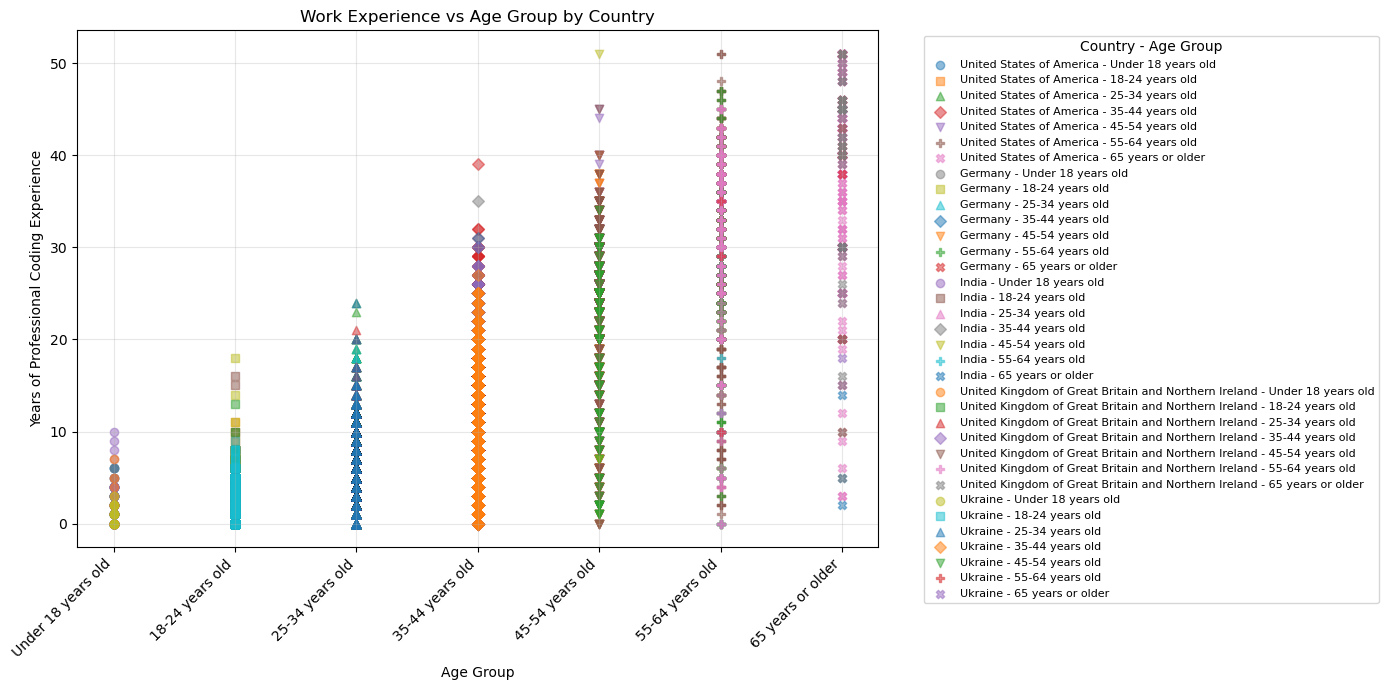

In [9]:
# Convert YearsCodePro to numeric
df['YearsCodePro_Numeric'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 51
})

df['YearsCodePro_Numeric'] = pd.to_numeric(
    df['YearsCodePro_Numeric'],
    errors='coerce'
)

# Keep only required columns and remove missing values
df_work = df[['Age', 'Country', 'YearsCodePro_Numeric']].dropna()

# Use top 5 countries to keep the chart readable
top_5_countries = df_work['Country'].value_counts().head(5).index
df_work = df_work[df_work['Country'].isin(top_5_countries)]

# Define age group order
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Keep only known age groups
df_work = df_work[df_work['Age'].isin(age_order)]

# Convert age groups to numeric positions for scatter plot
df_work['Age_Code'] = df_work['Age'].map({
    age: i for i, age in enumerate(age_order)
})

# Define marker styles for age groups
markers = {
    'Under 18 years old': 'o',
    '18-24 years old': 's',
    '25-34 years old': '^',
    '35-44 years old': 'D',
    '45-54 years old': 'v',
    '55-64 years old': 'P',
    '65 years or older': 'X'
}

# Create scatter plot
plt.figure(figsize=(14, 7))

for country in top_5_countries:
    country_data = df_work[df_work['Country'] == country]
    
    for age_group in age_order:
        subset = country_data[country_data['Age'] == age_group]
        
        if len(subset) > 0:
            plt.scatter(
                subset['Age_Code'],
                subset['YearsCodePro_Numeric'],
                marker=markers[age_group],
                alpha=0.5,
                label=f'{country} - {age_group}'
            )

plt.title('Work Experience vs Age Group by Country')
plt.xlabel('Age Group')
plt.ylabel('Years of Professional Coding Experience')
plt.xticks(
    ticks=range(len(age_order)),
    labels=age_order,
    rotation=45,
    ha='right'
)
plt.grid(True, alpha=0.3)

# Put legend outside the chart
plt.legend(
    title='Country - Age Group',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=8
)

plt.tight_layout()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
